In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sms

from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv("Salary_Data.csv")

In [3]:
df.shape

(30, 2)

In [4]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 608.0 bytes


In [6]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [7]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [9]:
X = df.drop(['Salary'],axis=1)
y = df['Salary']

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model1 = SVR(kernel='linear')
model1.fit(X_train,y_train)
y_pred1 = model1.predict(X_test)
print("MSE:",mean_squared_error(y_test,y_pred1))
print("MAE:",mean_absolute_error(y_test,y_pred1))
print("r2_score",r2_score(y_test,y_pred1))

MSE: 951479688.4627753
MAE: 22666.276108799928
r2_score -0.8627393197133859


In [13]:
model2 = SVR(kernel='rbf')
model2.fit(X_train,y_train)
y_pred2 = model2.predict(X_test)
print("MSE:",mean_squared_error(y_test,y_pred2))
print("MAE:",mean_absolute_error(y_test,y_pred2))
print("r2_score",r2_score(y_test,y_pred2))

MSE: 952217496.8844253
MAE: 22673.776560880142
r2_score -0.8641837486109101


In [14]:
model3 = SVR(kernel='poly')
model3.fit(X_train,y_train)
y_pred3 = model3.predict(X_test)
print("MSE:",mean_squared_error(y_test,y_pred3))
print("MAE:",mean_absolute_error(y_test,y_pred3))
print("r2_score",r2_score(y_test,y_pred3))

MSE: 950011787.9790021
MAE: 22653.21790806044
r2_score -0.8598655684586762


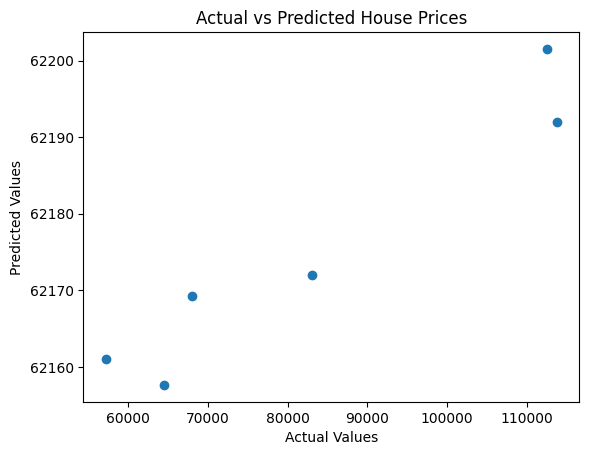

In [15]:
plt.scatter(y_test, y_pred1)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

param_grid = {
    'kernel':['rbf','linear'],
    'C':[1,10,100,1000],
    'epsilon':[0.01,0.1,1],
    'gamma':['scale','auto']
}

grid = GridSearchCV(SVR(),param_grid,cv=5,scoring='r2')

grid.fit(X_train,y_train)

print(grid.best_params_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("R2 Score:",r2_score(y_test,y_pred))

{'C': 1000, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'linear'}
R2 Score: 0.7042225790050203
